In [2]:
import pandas as pd


In [4]:
data = pd.read_csv("loan_dataset_messy.csv")

In [5]:
data.head()

,loan_id,age,gender,marital_status,education,self_employed,num_dependents,employment_years,income_annual,loan_amount,...,existing_loans,residential_assets,commercial_assets,bank_balance,monthly_expenses,property_area,loan_status,unnamed_col,row_number,random_notes
0,2095,62.0,M,Divorced,Graduate,N,2,4.0,21906.0,50177.0,...,4,226856,28069.0,NaN,27712.0,Rural,Approved,NaN,2094,check
1,1613,49.0,female,Divorced,Post Graduate,NO,2,22.0,78032.0,429726.0,...,3,693889,442275.0,279650.0,7263.0,semi-urban,Rejected,NaN,1612,NaN
2,5859,50.0,Male,Single,Post Graduate,No,0,4.0,49072.0,54282.0,...,4,659669,386940.0,249579.0,29434.0,urban,Rejected,NaN,5858,none
3,4295,56.0,Female,divorced,Not Graduate,No,1,27.0,188102.0,377860.0,...,4,847837,111215.0,164791.0,28482.0,urban,Approved,NaN,4294,NaN
4,2572,63.0,female,divorced,Grad,Y,1,24.0,NaN,395575.0,...,1,167400,490652.0,204920.0,30597.0,Urban,Approved,NaN,2571,NaN


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6120 entries, 0 to 6119
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             6120 non-null   int64  
 1   age                 5813 non-null   float64
 2   gender              5573 non-null   object 
 3   marital_status      5686 non-null   object 
 4   education           6120 non-null   object 
 5   self_employed       5627 non-null   object 
 6   num_dependents      6120 non-null   int64  
 7   employment_years    5509 non-null   float64
 8   income_annual       5628 non-null   float64
 9   loan_amount         5749 non-null   float64
 10  loan_term_months    6120 non-null   int64  
 11  loan_purpose        6120 non-null   object 
 12  credit_score        5692 non-null   object 
 13  existing_loans      6120 non-null   int64  
 14  residential_assets  6120 non-null   int64  
 15  commercial_assets   5818 non-null   float64
 16  bank_b

In [7]:
#dropping the useless columns 
data=  data.drop(['loan_id','random_notes','row_number','unnamed_col'],axis=1)

In [8]:
#checking and removing duplicates
data.duplicated().sum()
data = data.drop_duplicates()


In [9]:
#dealing with inconsistent data
#data['gender'].unique()
data['gender']= data['gender'].str.strip()
data['gender']= data['gender'].str.lower()

data['gender'] = data['gender'].replace({
    'm':'Male',
    'male':'Male',
    'f':'Female',
    'female':'Female'
})

In [10]:

data['self_employed']= data['self_employed'].str.strip()
data['self_employed']= data['self_employed'].str.lower()

data['self_employed']= data['self_employed'].replace({
    'n':'No',
    'no':'No',
    'y':'Yes',
    'yes':'Yes'
})

In [11]:

data['marital_status']= data['marital_status'].str.strip()
data['marital_status']= data['marital_status'].str.lower()

data['marital_status']= data['marital_status'].replace({
    'divorced':'Divorced',
    'single':'Single',
    'married':'Married'     
})

In [12]:

data['property_area']= data['property_area'].str.strip()
data['property_area']= data['property_area'].str.lower()

data['property_area']= data['property_area'].replace({
    'rural':'Rural',
    'urban':'Urban',
    'semi-urban':'Semi-urban',
    'semiurban':'Semi-urban'     
})

In [13]:

data['loan_purpose']= data['loan_purpose'].str.strip()
data['loan_purpose']= data['loan_purpose'].str.lower()

data['loan_purpose']= data['loan_purpose'].replace({
    'home':'Home',
    'education':'Education', 
    'personal':'Personal',
    'business':'Business',
    'medical':'Medical'
})


In [14]:
 # chnaging data tyoe of credit score
 
data['credit_score']= data['credit_score'].str.replace(' pts','').astype(float)


In [15]:

data = data[data['credit_score']<=900]

In [16]:
print(data['credit_score'].dtype)
print(data['credit_score'].unique())

float64
[764. 590. 366. 421. 483. 546. 345. 436. 822. 785. 388. 827. 660. 432.
 494. 541. 712. 335. 305. 438. 762. 755. 368. 484. 729. 641. 431. 367.
 513. 560. 622. 320. 763. 303. 407. 312. 375. 447. 387. 705. 683. 613.
 352. 395. 651. 500. 558. 430. 833. 800. 633. 811. 424. 772. 563. 780.
 443. 753. 824. 591. 585. 313. 658. 675. 667. 502. 670. 543. 721. 331.
 448. 744. 423. 304. 319. 698. 681. 317. 701. 474. 384. 588. 691. 737.
 329. 699. 364. 706. 552. 542. 564. 632. 620. 506. 640. 767. 419. 574.
 365. 394. 341. 768. 374. 639. 752. 844. 501. 429. 738. 711. 602. 445.
 648. 684. 837. 449. 629. 531. 360. 708. 816. 358. 761. 746. 401. 576.
 747. 334. 485. 656. 607. 695. 522. 796. 453. 638. 700. 719. 422. 823.
 601. 537. 779. 465. 306. 661. 673. 654. 778. 471. 518. 322. 650. 807.
 771. 349. 410. 751. 450. 490. 357. 565. 627. 414. 300. 817. 508. 539.
 678. 674. 593. 356. 371. 385. 832. 819. 321. 598. 634. 842. 790. 348.
 604. 680. 696. 549. 808. 736. 398. 389. 373. 399. 316. 346. 610. 413

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5561 entries, 0 to 6118
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 5283 non-null   float64
 1   gender              5064 non-null   object 
 2   marital_status      5166 non-null   object 
 3   education           5561 non-null   object 
 4   self_employed       5109 non-null   object 
 5   num_dependents      5561 non-null   int64  
 6   employment_years    5014 non-null   float64
 7   income_annual       5124 non-null   float64
 8   loan_amount         5228 non-null   float64
 9   loan_term_months    5561 non-null   int64  
 10  loan_purpose        5561 non-null   object 
 11  credit_score        5561 non-null   float64
 12  existing_loans      5561 non-null   int64  
 13  residential_assets  5561 non-null   int64  
 14  commercial_assets   5284 non-null   float64
 15  bank_balance        5226 non-null   float64
 16  monthly_exp

In [18]:
data['age'] = data['age'].fillna(data['age'].median())
data['gender']= data['gender'].fillna(data['gender'].mode()[0])
data['marital_status']= data['marital_status'].fillna(data['marital_status'].mode()[0])
data['self_employed']= data['self_employed'].fillna(data['self_employed'].mode()[0])
data['employment_years']= data['employment_years'].fillna(data['employment_years'].median())
data['income_annual']= data['income_annual'].fillna(data['income_annual'].median())
data['loan_amount']= data['loan_amount'].fillna(data['loan_amount'].median())
data['commercial_assets']= data['commercial_assets'].fillna(data['commercial_assets'].median())
data['bank_balance']= data['bank_balance'].fillna(data['bank_balance'].median())
data['monthly_expenses']= data['monthly_expenses'].fillna(data['monthly_expenses'].median())



In [20]:
data.select_dtypes(include='object').columns

Index(['gender', 'marital_status', 'education', 'self_employed',
       'loan_purpose', 'property_area', 'loan_status'],
      dtype='object')

In [22]:
from sklearn.preprocessing import LabelEncoder

lr = LabelEncoder()
data['loan_status']= lr.fit_transform(data['loan_status'])

data= pd.get_dummies(data,columns=['gender','marital_status','education','self_employed',
                                   'loan_purpose','property_area',],dtype=int)

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5561 entries, 0 to 6118
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       5561 non-null   float64
 1   num_dependents            5561 non-null   int64  
 2   employment_years          5561 non-null   float64
 3   income_annual             5561 non-null   float64
 4   loan_amount               5561 non-null   float64
 5   loan_term_months          5561 non-null   int64  
 6   credit_score              5561 non-null   float64
 7   existing_loans            5561 non-null   int64  
 8   residential_assets        5561 non-null   int64  
 9   commercial_assets         5561 non-null   float64
 10  bank_balance              5561 non-null   float64
 11  monthly_expenses          5561 non-null   float64
 12  loan_status               5561 non-null   int64  
 13  gender_Female             5561 non-null   int64  
 14  gender_Male  

In [24]:
# EDA STARTS

In [25]:
data["loan_status"].value_counts()

loan_status
0    4282
1    1279
Name: count, dtype: int64

In [30]:
import matplotlib.pyplot as plt

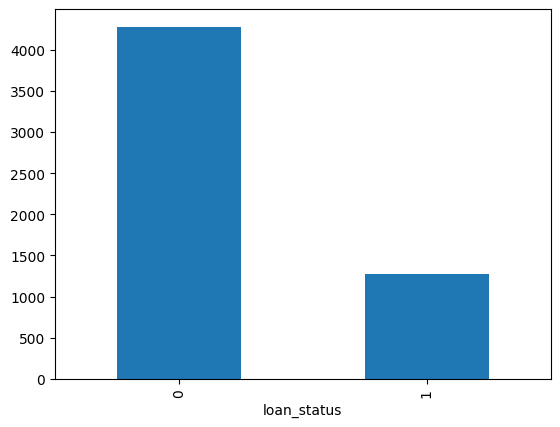

In [31]:
data["loan_status"].value_counts().plot(kind='bar')
plt.show()

In [33]:
lr.classes_

array(['Approved', 'Rejected'], dtype=object)

In [32]:
data.groupby("loan_status")["credit_score"].mean()

loan_status
0    599.492293
1    493.974199
Name: credit_score, dtype: float64

In [37]:
data.groupby('loan_status')['income_annual'].mean()
 

loan_status
0    153848.343298
1     69445.544957
Name: income_annual, dtype: float64

In [39]:
data.groupby("loan_status")["loan_amount"].mean()

loan_status
0    245923.370154
1    310028.231040
Name: loan_amount, dtype: float64

In [40]:
from sklearn.model_selection import train_test_split

In [43]:
X = data.drop(['loan_status'],axis=1)
Y = data["loan_status"]

In [45]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [46]:
from sklearn.linear_model import LogisticRegression

In [49]:
lr = LogisticRegression()
lr.fit(X_train,Y_train)

c:\Users\Ubaid Mughal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [51]:
pred1 = lr.predict(X_test)
print(pred1)

[0 0 0 ... 1 0 0]


In [52]:
from sklearn.metrics import accuracy_score

In [53]:
accuracy = accuracy_score(Y_test,pred1)
print(accuracy)

0.834681042228212


In [54]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(Y_test,pred1)
print(cm)


[[854  29]
 [155  75]]


In [55]:
# presicion and reacall
from sklearn.metrics import classification_report
print(classification_report(Y_test,pred1))

              precision    recall  f1-score   support

           0       0.85      0.97      0.90       883
           1       0.72      0.33      0.45       230

    accuracy                           0.83      1113
   macro avg       0.78      0.65      0.68      1113
weighted avg       0.82      0.83      0.81      1113



In [57]:
lr2 = LogisticRegression(class_weight='balanced')
lr2.fit(X_train,Y_train)

c:\Users\Ubaid Mughal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [58]:
pred2 = lr2.predict(X_test)
print(pred2)

[0 0 0 ... 1 0 0]


In [59]:
acc2 = accuracy_score(Y_test,pred2)
print(acc2)

0.7996406109613656


In [60]:
print(classification_report(Y_test,pred2))

              precision    recall  f1-score   support

           0       0.92      0.82      0.87       883
           1       0.51      0.72      0.60       230

    accuracy                           0.80      1113
   macro avg       0.71      0.77      0.73      1113
weighted avg       0.83      0.80      0.81      1113



In [61]:
probs = lr.predict_proba(X_test)
print(probs)

[[0.9295131  0.0704869 ]
 [0.92671411 0.07328589]
 [0.87265869 0.12734131]
 ...
 [0.48815931 0.51184069]
 [0.8160546  0.1839454 ]
 [0.84584435 0.15415565]]


In [62]:
# fixing rejection
prob2 = lr2.predict_proba(X_test)[:,1]
pred_new = (prob2 > 0.6).astype(int)

In [ ]:
print(confusion_matrix(Y_test, pred_new))
print(classification_report(Y_test, pred_new))
print("Accuracy:", accuracy_score(Y_test, pred_new))


[[790  93]
 [ 90 140]]
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       883
           1       0.60      0.61      0.60       230

    accuracy                           0.84      1113
   macro avg       0.75      0.75      0.75      1113
weighted avg       0.84      0.84      0.84      1113

Accuracy: 0.8355795148247979


In [65]:
# using descsion tree model
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train,Y_train)
pred3 = dt.predict(X_test)

In [66]:
print(confusion_matrix(Y_test,pred3))
print(accuracy_score(Y_test,pred3))
print(classification_report(Y_test,pred3))

[[842  41]
 [ 20 210]]
0.945193171608266
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       883
           1       0.84      0.91      0.87       230

    accuracy                           0.95      1113
   macro avg       0.91      0.93      0.92      1113
weighted avg       0.95      0.95      0.95      1113



In [67]:
# random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,Y_train)
pred4 = rf.predict(X_test)

print(accuracy_score(Y_test,pred4))
print(confusion_matrix(Y_test,pred4))
print(classification_report(Y_test,pred4))

0.945193171608266
[[875   8]
 [ 53 177]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       883
           1       0.96      0.77      0.85       230

    accuracy                           0.95      1113
   macro avg       0.95      0.88      0.91      1113
weighted avg       0.95      0.95      0.94      1113

